## Heatload om M2 mirror
awojdyla@lbl.gov, March 2026

Notes (late Feb 2026):
+ M0 aperture reduced to 0.4 mrad
+ changed M0 to 1.20 and M1 to 2.25 deg
+ increased the simulations precision and max energy (spectra results series 78)

## Flux through an aperture

In [68]:
import numpy as np
import matplotlib.pyplot as plt 

import json

N_f = 201
E_list_eV = np.zeros(N_f)

full_flux_list_ph_ps_p01BW = np.zeros(N_f)
apertured_flux_list_ph_ps_p01BW = np.zeros(N_f)

for i_f in range(1, N_f) :
    #print(f'Processing file {i_f} of {N_f-1}')
    filename = f'../data/spectra-ssrl/ssrl_10_1-79_{i_f}.json'
    # Replace 'data.json' with the path to your file


    with open(filename, 'r') as file:
        data = json.load(file)

    E_eV = data['Output']['Set Value']
    xp_mrad = data['Output']['data'][0]
    xp_mrad = data['Output']['data'][0]
    yp_mrad = data['Output']['data'][1]
    flux_ph_ps_p01BW = data['Output']['data'][2]

    X,Y = np.meshgrid(xp_mrad, yp_mrad)
    flux_density_ph_ps_p01BW= np.array(flux_ph_ps_p01BW).reshape(len(yp_mrad), len(xp_mrad))

    mask_x = (X < 2.25) | (X > 2.75)
    mask_y = (Y > 0.4)
    flux_aperture_density_ph_ps_p01BW = flux_density_ph_ps_p01BW.copy()
    flux_aperture_density_ph_ps_p01BW[mask_x | mask_y] = 0

    dx_mrad = xp_mrad[1] - xp_mrad[0]
    dy_mrad = yp_mrad[1] - yp_mrad[0]

    full_flux_ph_ps_p01BW      = 2*np.sum(flux_density_ph_ps_p01BW) * dx_mrad * dy_mrad
    apertured_flux_ph_ps_p01BW = 2*np.sum(flux_aperture_density_ph_ps_p01BW) * dx_mrad * dy_mrad

    E_list_eV[i_f] = E_eV
    full_flux_list_ph_ps_p01BW[i_f] = full_flux_ph_ps_p01BW
    apertured_flux_list_ph_ps_p01BW[i_f] = apertured_flux_ph_ps_p01BW

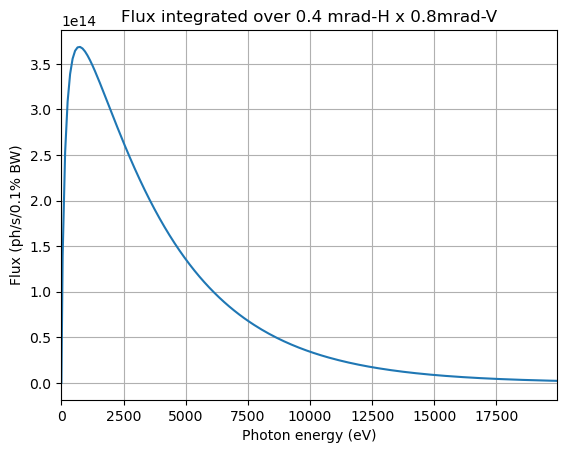

In [70]:
plt.plot(E_list_eV, apertured_flux_list_ph_ps_p01BW, label='Full flux')
plt.xlabel('Photon energy (eV)')
plt.ylabel('Flux (ph/s/0.1% BW)')
plt.title('Flux integrated over 0.4 mrad-H x 0.8mrad-V')
plt.xlim(0,  np.max(E_list_eV))
plt.grid()
plt.show()

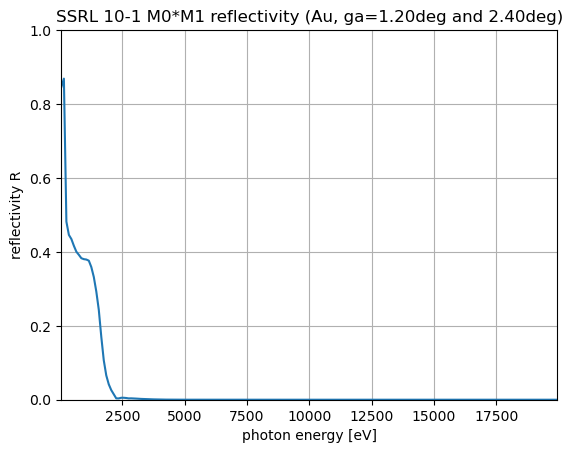

In [71]:
import xrt.backends.raycing.materials as rm
import matplotlib.pyplot as plt
import periodictable as pt
import numpy as np

rho = pt.Au.density
mat = rm.Material('Au',table='Henke',rho=rho)

energies_eV = E_list_eV
energies_eV[energies_eV<50] = 50
N_i = N_f


R_M0 = np.zeros(N_i)
R_M1 = np.zeros(N_i)
ga_M0_rad = 1.20*np.pi/180
for i in np.arange(N_i):
    beamInDotNormal = np.cos(np.pi/2-ga_M0_rad)
    (rs,rp,c,d) = mat.get_amplitude(energies_eV[i],beamInDotNormal)
    R_M0[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)

ga_M1_rad = 2.40*np.pi/180
for i in np.arange(N_i):
    beamInDotNormal = np.cos(np.pi/2-ga_M1_rad)
    (rs,rp,c,d) = mat.get_amplitude(energies_eV[i],beamInDotNormal)
    R_M1[i] = 0.5*(np.abs(rs)**2+np.abs(rp)**2)

plt.plot(energies_eV, R_M0*R_M1)
#plt.plot(energies_eV, Rs, energies_eV, Rp)
plt.xlabel('photon energy [eV]')
plt.ylabel('reflectivity R')
plt.title('SSRL 10-1 M0*M1 reflectivity (Au, ga=%1.2fdeg and %1.2fdeg)' %(ga_M0_rad*180/np.pi, ga_M1_rad*180/np.pi))
plt.xlim((np.min(energies_eV),np.max(energies_eV)))
plt.ylim((0,1))
plt.grid()
plt.show()


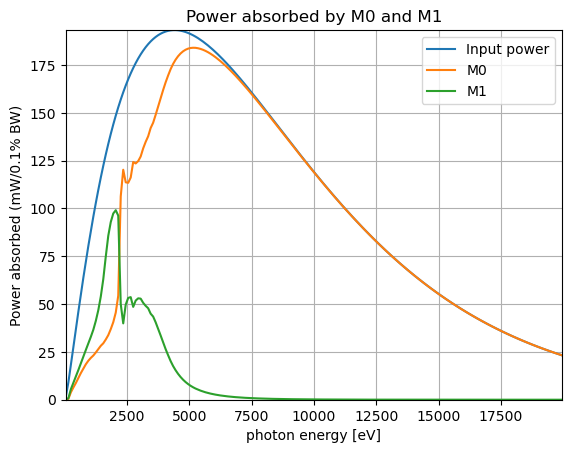

In [ ]:
# power absorbed by M0 and M1
P_in = full_flux_list_ph_ps_p01BW * energies_eV * 1.60218e-19
P_M0 = full_flux_list_ph_ps_p01BW * energies_eV * 1.60218e-19 * (1-R_M0)
P_M1 = full_flux_list_ph_ps_p01BW * energies_eV * 1.60218e-19 * R_M0 * (1-R_M1)
plt.plot(energies_eV, P_in*1e3, label='Input power')
plt.plot(energies_eV, P_M0*1e3, label='M0')
plt.plot(energies_eV, P_M1*1e3, label='M1')
plt.xlabel('photon energy [eV]')
plt.ylabel('Power absorbed (mW/0.1% BW)')
plt.title('Power absorbed by M0 and M1')
plt.xlim((np.min(energies_eV),np.max(energies_eV)))
plt.ylim((0, np.max(P_in)*1e3))
plt.legend()
plt.grid()

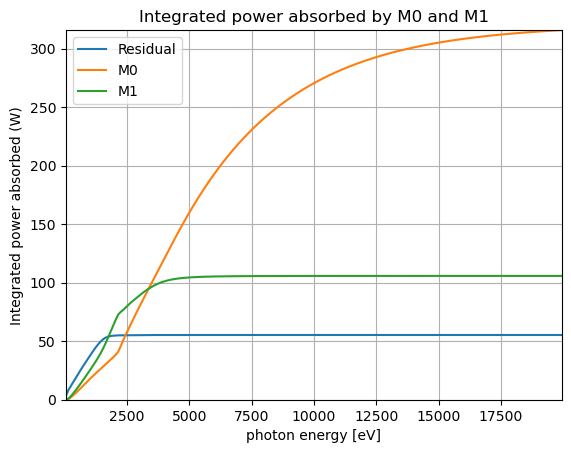

In [94]:
# total power absorbed by M0 and M1
pcbw = (energies_eV[2] - energies_eV[1])/energies_eV*1000


integrated_P_M0 = np.cumsum(P_M0*pcbw)
integrated_P_M1 = np.cumsum(P_M1*pcbw)
integrated_P_res= np.cumsum(P_in*pcbw) - integrated_P_M0 - integrated_P_M1
plt.plot(energies_eV, integrated_P_res, label='Residual')
plt.plot(energies_eV, integrated_P_M0, label='M0')
plt.plot(energies_eV, integrated_P_M1, label='M1')

plt.xlabel('photon energy [eV]')
plt.ylabel('Integrated power absorbed (W)')
plt.title('Integrated power absorbed by M0 and M1')
plt.xlim(energies_eV[0], energies_eV[-1])
plt.ylim(0, np.max(integrated_P_M0))
plt.legend()   
plt.grid()
plt.show()


In [101]:
P_inc_M2 = np.sum(full_flux_list_ph_ps_p01BW * energies_eV * 1.60218e-19 * R_M0 * R_M1 *pcbw)
print('Power incident by M2: %1.2f W' %(P_inc_M2))

Power incident by M2: 55.32 W


In [95]:
from scipy.io import loadmat

# Load the MATLAB file
matlab_file_path = '../data/matlab-ssrl/LEG_a.mat'
matlab_data = loadmat(matlab_file_path)

In [97]:
cff = matlab_data['cff'].flatten()
Em_eV = matlab_data['Es_eV'].flatten()
etas_blaze = matlab_data['etas_blaze'].flatten()  
g_lpm = matlab_data['g_lpm'].flatten()
thetas_rad = matlab_data['thetas_rad'].flatten()

thetas_rad_interp = np.interp(energies_eV, Em_eV, thetas_rad)

Text(0.5, 1.0, 'SSRL 10-1 M2 at LEG max grazing angle 11.35deg')

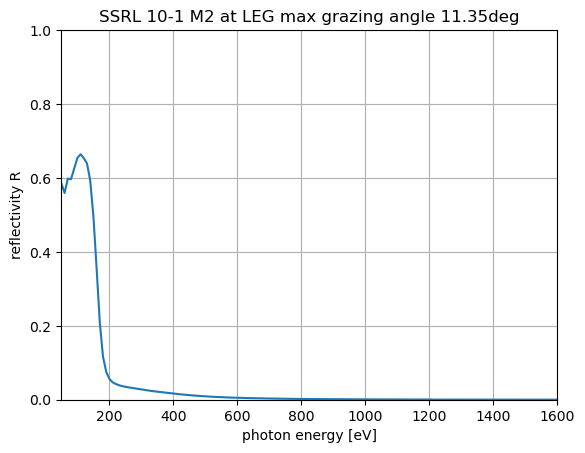

In [117]:

beamInDotNormal = np.cos(thetas_rad[0])
(rs,rp,c,d) = mat.get_amplitude(Em_eV,beamInDotNormal)
R_M2_max = 0.5*(np.abs(rs)**2+np.abs(rp)**2)
plt.plot(Em_eV,R_M2_max)
plt.xlabel('photon energy [eV]')
plt.ylabel('reflectivity R')
plt.xlim((50,1600))
plt.ylim((0,1))
plt.grid()
plt.title('SSRL 10-1 M2 at LEG max grazing angle %1.2fdeg' %(90- thetas_rad[0]*180/np.pi))

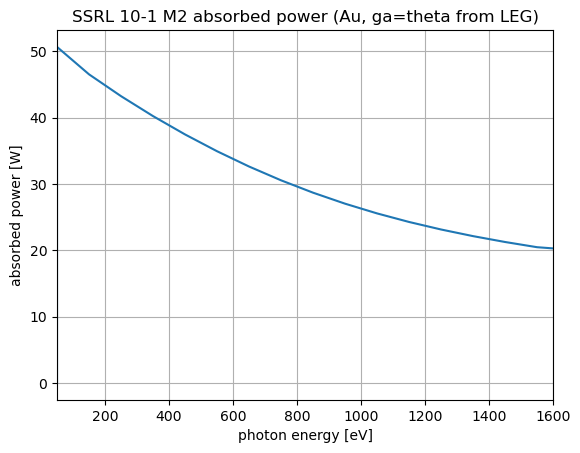

In [107]:
R_M2 = np.zeros(E_list_eV.shape)
P_M2 = np.zeros(E_list_eV.shape)
for i in np.arange(E_list_eV.shape[0]):
    if i!= 0:
        beamInDotNormal = np.cos(thetas_rad_interp[i])
        (rs,rp,c,d) = mat.get_amplitude(energies_eV,beamInDotNormal)
        R_M2 = 0.5*(np.abs(rs)**2+np.abs(rp)**2)
        P_M2[i] = np.sum(full_flux_list_ph_ps_p01BW * energies_eV * 1.60218e-19 * R_M0 * R_M1 * (1-R_M2)*pcbw)

plt.plot(energies_eV, P_M2)
plt.xlabel('photon energy [eV]')
plt.ylabel('absorbed power [W]')
plt.title('SSRL 10-1 M2 absorbed power (Au, ga=theta from LEG)')
plt.xlim((50, 1600))
plt.grid()
plt.show()


